# Construction d'un parcours du Tour de France

Ce notebook utilise des données géographiques, le clustering et des heuristiques d'optimisation pour concevoir un Tour de France 2027. Il regroupe 120 villages en 21 étapes, puis cherche un ordre de passage court pour chaque étape.

## Importer les bibliothèques

Cette cellule importe les outils de calcul, de visualisation et de machine learning nécessaires au chargement des villages, au clustering et à la construction du parcours.

In [2]:
import math

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from utils import (
    load_villages,
    plot_villages,
    plot_stages,
    plot_stage_zoom,
    plot_final_tour,
    print_roadbook,
)

## Charger les villages

Cette cellule lit le fichier `villages_2027.csv`, affiche un aperçu des données et vérifie que les 120 villages et les colonnes attendues sont présents.

In [3]:
villages = load_villages("villages_2027.csv")

print(f"{len(villages)} villages au programme du Tour 2027")
display(villages.head())

assert len(villages) == 120, f"Le fichier devrait contenir 120 villages, il y en a {len(villages)}"
assert list(villages.columns) == ["village", "departement", "latitude", "longitude"], "Colonnes inattendues"
print("Données chargées, on peut y aller !")

120 villages au programme du Tour 2027


,village,departement,latitude,longitude
0,Aiguèze,30,44.30342,4.55532
1,Angles-sur-l'Anglin,86,46.69547,0.88455
2,Ansouis,84,43.73754,5.46397
3,Apremont-sur-Allier,18,46.90640,3.04751
4,Arlempdes,43,44.86556,3.92273


Données chargées, on peut y aller !


## Explorer la répartition géographique

Cette cellule compte les villages par département et visualise les départements les plus représentés dans la sélection.

departement
17    4
12    4
19    4
30    3
84    3
43    3
46    3
82    3
64    3
83    3
Name: count, dtype: int64

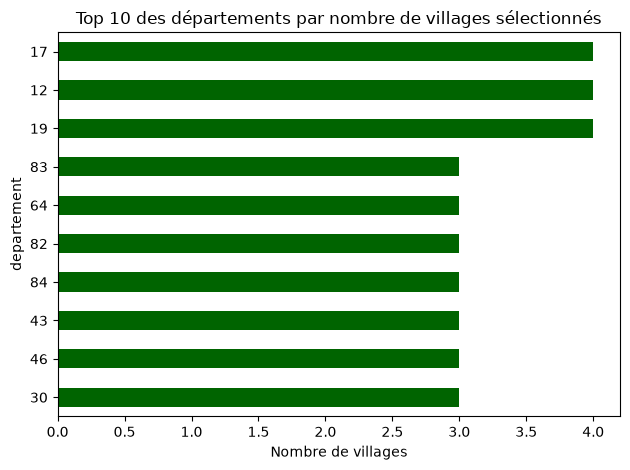

Exercice validé ! L'Aveyron, la Charente-Maritime et la Corrèze se partagent la tête.


In [5]:
villages_per_dept = villages.value_counts("departement").head(10)

display(villages_per_dept)

villages_per_dept.sort_values().plot(kind="barh", color="darkgreen")
plt.title("Top 10 des départements par nombre de villages sélectionnés")
plt.xlabel("Nombre de villages")
plt.tight_layout()
plt.show()

assert len(villages_per_dept) == 10, f"Il faut un top 10, tu as {len(villages_per_dept)} lignes"
assert villages_per_dept.max() == 4, "Le maximum devrait être de 4 villages pour un même département"
print("Exercice validé ! L'Aveyron, la Charente-Maritime et la Corrèze se partagent la tête.")

## Visualiser les villages

Cette cellule représente les villages sur une carte afin d'observer leur répartition géographique avant de former les étapes.

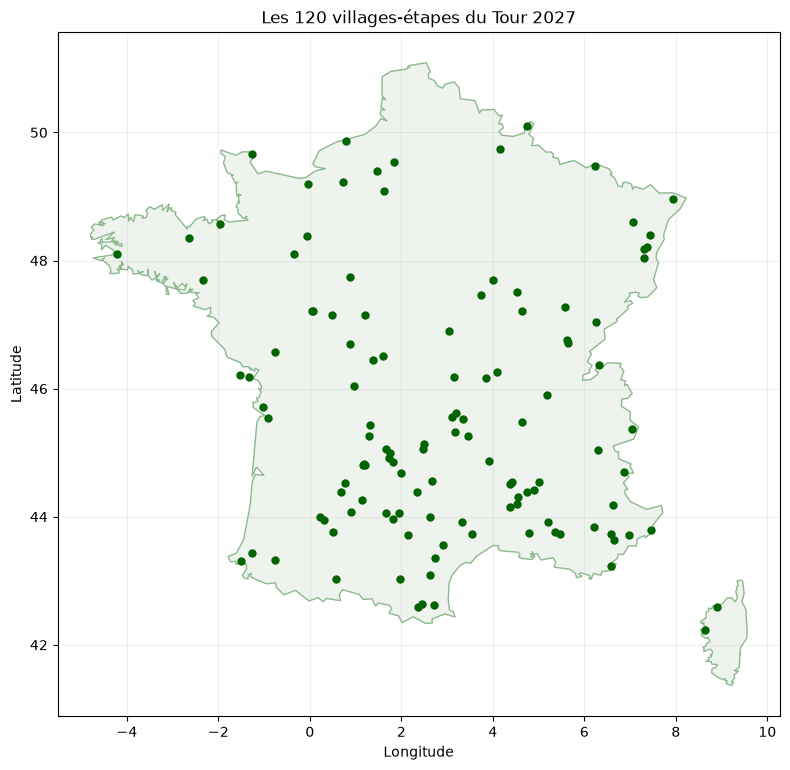

In [6]:
plot_villages(villages)

## Convertir les coordonnées en kilomètres

Cette cellule transforme les latitudes et longitudes en coordonnées approximatives en kilomètres pour permettre des calculs de distance adaptés au clustering.

In [7]:
lat_mean = villages["latitude"].mean()
print(f"Latitude moyenne de nos villages : {lat_mean:.2f}° (1 degré de longitude y vaut {111 * math.cos(math.radians(lat_mean)):.0f} km)")

villages["y_km"] = villages["latitude"] * 111
villages["x_km"] = villages["longitude"] * 111 * math.cos(math.radians(lat_mean))

display(villages.head())

assert "x_km" in villages.columns and "y_km" in villages.columns, "Il manque les colonnes x_km et y_km"
assert abs(villages["y_km"].iloc[0] - villages["latitude"].iloc[0] * 111) < 1e-6, "y_km doit valoir latitude x 111"
assert abs(villages["x_km"].iloc[0] - villages["longitude"].iloc[0] * 111 * math.cos(math.radians(lat_mean))) < 1e-6, \
    "x_km doit valoir longitude x 111 x cos(lat_mean en radians)"
assert 800 < villages["y_km"].max() - villages["y_km"].min() < 1000, \
    "Du village le plus au nord au plus au sud, il devrait y avoir environ 870 km"
print("Exercice validé ! Nos villages vivent maintenant dans un plan en kilomètres.")

Latitude moyenne de nos villages : 45.63° (1 degré de longitude y vaut 78 km)


,village,departement,latitude,longitude,y_km,x_km
0,Aiguèze,30,44.30342,4.55532,4917.67962,353.579258
1,Angles-sur-l'Anglin,86,46.69547,0.88455,5183.19717,68.657862
2,Ansouis,84,43.73754,5.46397,4854.86694,424.107737
3,Apremont-sur-Allier,18,46.90640,3.04751,5206.61040,236.544595
4,Arlempdes,43,44.86556,3.92273,4980.07716,304.478272


Exercice validé ! Nos villages vivent maintenant dans un plan en kilomètres.


## Regrouper les villages avec K-Means

Cette cellule applique l'algorithme K-Means pour répartir les 120 villages en 21 groupes géographiques et affiche le résultat sur la carte.

[20 16  0  9 20 14  2  5 12 20  7 17  3 19  6  1 15 13 19  5 10  4  2  2
 19  2 10 15  3  9  2 17 19  4  2  2  6 19 10  9  5 16 17  1  0 17 20 18
  6  6 12 19 14 20 13  1  2 20 10  5 19  5  5  4 15  1  9 20  0  7  3  0
 20  1 19  6  7  5 15 16  4 14 16 17 12  9 19 18  3  8  5  3  7 11 16 10
  4 15 19  6  2  7 13 17 20  4 15  8 17  9  2 14 15 15  1 10 20 14  9  3]
21 étapes créées, étiquettes de 0 à 20


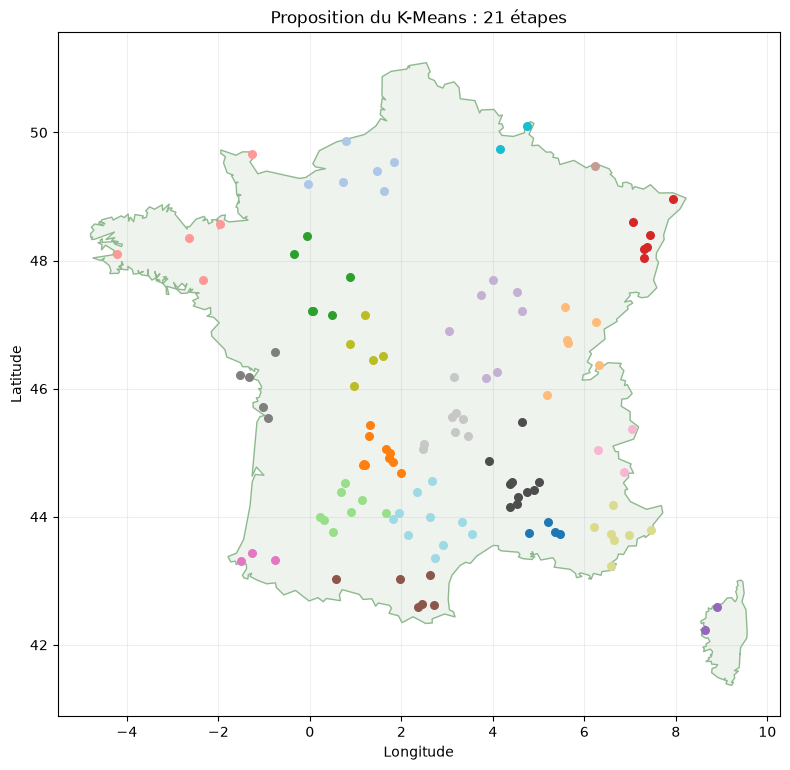

Exercice validé !


In [ ]:
N_STAGES = 21

kmeans = KMeans(n_clusters=N_STAGES, random_state=42)
labels_kmeans = kmeans.fit_predict(villages[["x_km", "y_km"]])

print(f"{len(set(labels_kmeans))} étapes créées, étiquettes de {labels_kmeans.min()} à {labels_kmeans.max()}")
plot_stages(villages, labels_kmeans, title="Proposition du K-Means : 21 étapes")

assert len(labels_kmeans) == 120, "Il faut une étiquette par village"
assert len(set(labels_kmeans)) == 21, f"Il faut 21 étapes, tu en as {len(set(labels_kmeans))}"


## Regrouper les villages avec une CAH

Cette cellule applique le clustering hiérarchique agglomératif afin de créer une seconde proposition de 21 étapes à comparer avec K-Means.

21 étapes créées


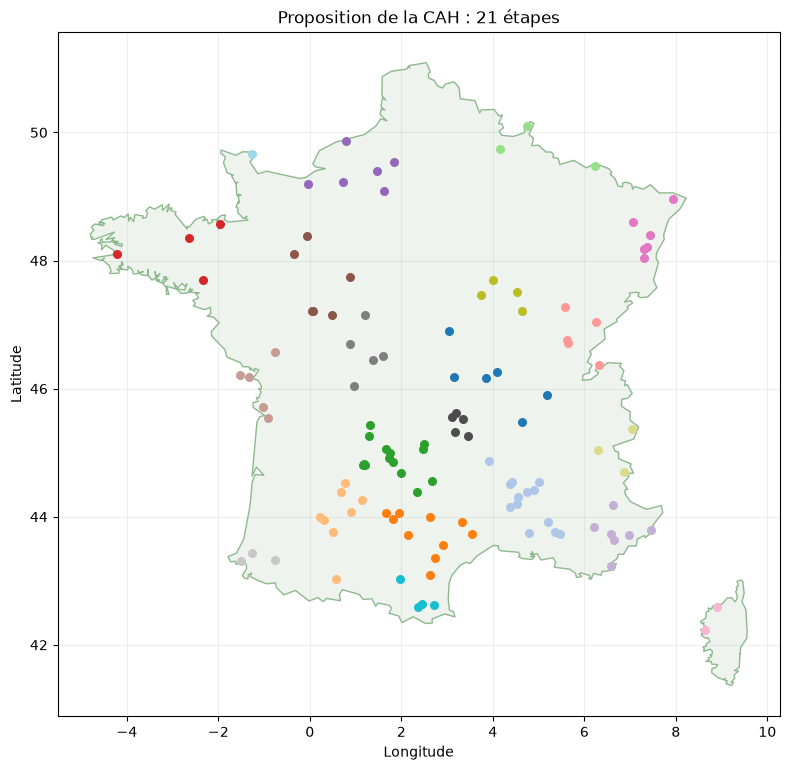

Exercice validé !


In [ ]:
cah = AgglomerativeClustering(n_clusters=N_STAGES, linkage="ward")
labels_cah = cah.fit_predict(villages[["x_km", "y_km"]])

print(f"{len(set(labels_cah))} étapes créées")
plot_stages(villages, labels_cah, title="Proposition de la CAH : 21 étapes")

assert len(labels_cah) == 120, "Il faut une étiquette par village"
assert len(set(labels_cah)) == 21, f"Il faut 21 étapes, tu en as {len(set(labels_cah))}"


## Comparer la qualité des regroupements

Cette cellule compare K-Means et la CAH avec le score de silhouette et la taille des groupes, puis visualise les différences entre les deux propositions.

Silhouette K-Means : 0.461 | étapes de 1 à 10 villages
Silhouette CAH     : 0.467 | étapes de 1 à 14 villages


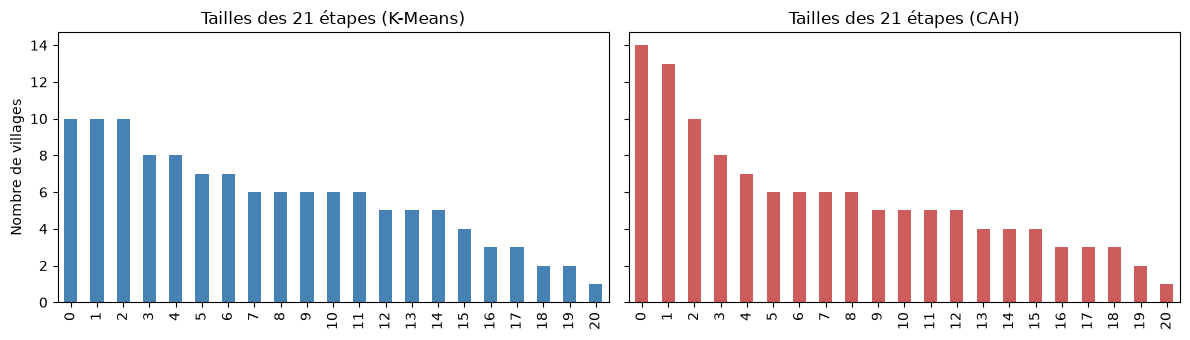

Exercice validé !


In [ ]:
sil_kmeans = silhouette_score(villages[["x_km", "y_km"]], labels_kmeans, random_state=42)
sil_cah = silhouette_score(villages[["x_km", "y_km"]], labels_cah)

sizes_kmeans = pd.Series(labels_kmeans).value_counts()
sizes_cah = pd.Series(labels_cah).value_counts()

print(f"Silhouette K-Means : {sil_kmeans:.3f} | étapes de {sizes_kmeans.min()} à {sizes_kmeans.max()} villages")
print(f"Silhouette CAH     : {sil_cah:.3f} | étapes de {sizes_cah.min()} à {sizes_cah.max()} villages")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
sizes_kmeans.sort_values(ascending=False).reset_index(drop=True).plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Tailles des 21 étapes (K-Means)")
axes[0].set_ylabel("Nombre de villages")
sizes_cah.sort_values(ascending=False).reset_index(drop=True).plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Tailles des 21 étapes (CAH)")
plt.tight_layout()
plt.show()

assert 0.30 < sil_kmeans < 0.60, f"La silhouette du K-Means devrait avoisiner 0.46, tu obtiens {sil_kmeans:.3f}"
assert 0.30 < sil_cah < 0.60, f"La silhouette de la CAH devrait avoisiner 0.47, tu obtiens {sil_cah:.3f}"
assert sizes_kmeans.sum() == 120 and sizes_cah.sum() == 120, "Chaque village doit appartenir à une étape"


## Définir les 21 étapes officielles

Cette cellule retient les groupes issus de K-Means, les renumérote du nord au sud pour obtenir un ordre lisible et affiche la carte finale des étapes. Pourquoi K-Means et non CAH ? Selon le silhouhette_score, CAH est légèrement meilleur. Cependant, le K-Means produit des groupes moins dispersés en taille, avec des étapes comprenant entre 1 et 10 villages contre 1 à 14 pour la CAH. Cette répartition est plus homogène et donc plus adaptée à la construction de 21 étapes de tournée

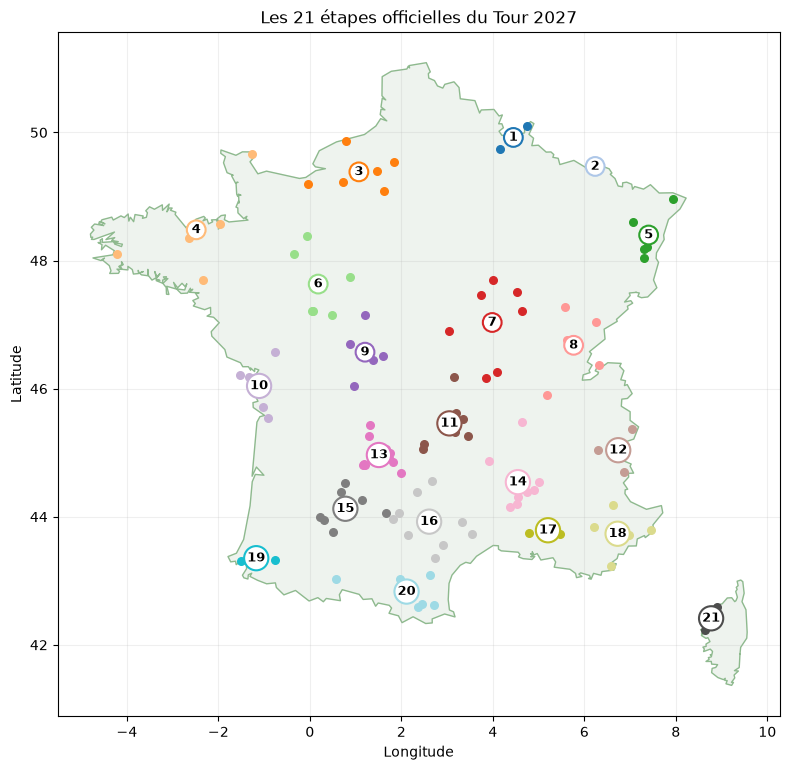

Mission 1 accomplie : la France est découpée en 21 étapes !


In [21]:
villages["stage"] = labels_kmeans

# on renumérote les étapes du nord au sud : plus lisible qu'une numérotation arbitraire
stage_order = villages.groupby("stage")["latitude"].mean().sort_values(ascending=False).index
villages["stage"] = villages["stage"].map({old: new + 1 for new, old in enumerate(stage_order)})

plot_stages(villages, villages["stage"], title="Les 21 étapes officielles du Tour 2027", numbered=True)

assert set(villages["stage"]) == set(range(1, 22)), "Les étapes doivent être numérotées de 1 à 21"
print("Mission 1 accomplie : la France est découpée en 21 étapes !")

## Calculer les distances géographiques

Cette cellule définit la formule de Haversine, qui calcule la distance en kilomètres entre deux points GPS à la surface de la Terre.

In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    """Compute the great-circle distance between two GPS points, in kilometers.

    Arguments:
    lat1, lon1 -- latitude and longitude of the first point, in degrees
    lat2, lon2 -- latitude and longitude of the second point, in degrees

    Returns:
    distance -- distance between the two points, in kilometers
    """
    earth_radius = 6371

    rad_lat1, rad_lat2 = math.radians(lat1), math.radians(lat2)

    delta_lat, delta_lon = math.radians(lat1 - lat2), math.radians(lon1 - lon2)

    a = math.sin(delta_lat / 2) ** 2 + math.cos(rad_lat1) * math.cos(rad_lat2) * math.sin(delta_lon / 2) ** 2

    distance = 2 * earth_radius * math.asin(a ** 0.5)

    return distance


paris_marseille = haversine(48.8566, 2.3522, 43.2965, 5.3698)
print(f"Paris - Marseille à vol d'oiseau : {paris_marseille:.0f} km")

assert 640 < paris_marseille < 680, f"Paris-Marseille devrait faire environ 660 km, tu obtiens {paris_marseille:.0f}"
assert abs(haversine(48.8566, 2.3522, 43.2965, 5.3698) - haversine(43.2965, 5.3698, 48.8566, 2.3522)) < 1e-9, \
    "La distance doit être la même dans les deux sens !"
assert haversine(45.0, 3.0, 45.0, 3.0) == 0, "La distance d'un point à lui-même doit être nulle"


Paris - Marseille à vol d'oiseau : 660 km
Exercice validé !


## Construire la matrice des distances

Cette cellule calcule les distances entre toutes les paires de villages afin de disposer des coûts de déplacement nécessaires à l'optimisation des étapes.

In [ ]:
coords = list(zip(villages["latitude"], villages["longitude"]))
n_villages = len(coords)

distances = [[haversine(lat1, lon1, lat2, lon2) for lat2, lon2 in coords] for lat1, lon1 in coords]

print(f"Matrice {len(distances)} x {len(distances[0])} calculée")
print(f"Distance entre {villages['village'][0]} et {villages['village'][1]} : {distances[0][1]:.0f} km")

assert len(distances) == 120 and len(distances[0]) == 120, "La matrice doit faire 120 x 120"
assert all(distances[i][i] == 0 for i in range(120)), "La diagonale doit être nulle (village vers lui-même)"
assert abs(distances[3][77] - distances[77][3]) < 1e-9, "La matrice doit être symétrique"
assert max(max(row) for row in distances) < 1300, "Aucune paire de villages français ne dépasse 1300 km"


Matrice 120 x 120 calculée
Distance entre Aiguèze et Angles-sur-l'Anglin : 391 km
Exercice validé !


## Définir la longueur d'un parcours

Cette cellule crée une fonction qui additionne les distances entre villages successifs d'un parcours ouvert, sans ajouter de retour au point de départ.

In [ ]:
def path_distance(path):
    """Compute the total length of an open path through the villages.

    Arguments:
    path -- list of village indices, in visiting order

    Returns:
    total -- total distance of the path in kilometers, no return trip
    """

    total = 0
    for i in range(len(path) - 1):
        total += distances[path[i]][path[i + 1]]

    return total


assert path_distance([0, 1]) == distances[0][1], \
    "Sur deux villages, le parcours fait UN aller, pas d'aller-retour : as-tu ajouté un retour en trop ?"
assert abs(path_distance([0, 1, 2]) - (distances[0][1] + distances[1][2])) < 1e-9, \
    "Vérifie le calcul sur trois villages : 0 vers 1, puis 1 vers 2, et c'est tout"

route_naive = list(range(n_villages))
naive_distance = path_distance(route_naive)
print(f"Parcours naïf des 120 villages (ordre alphabétique du fichier) : {naive_distance:.0f} km")

assert 44000 < naive_distance < 49000, f"Le parcours alphabétique devrait faire environ 47 000 km"


Parcours naïf des 120 villages (ordre alphabétique du fichier) : 46789 km
Exercice validé !


## Mesurer la difficulté d'une recherche exhaustive

Cette cellule calcule le nombre de parcours possibles pour 120 villages afin de montrer pourquoi il est impossible de tous les tester directement.

In [32]:
nb_paths = math.factorial(120) // 2

print(f"Nombre d'ordres possibles pour 120 villages : un nombre à {len(str(nb_paths))} chiffres")
print(f"Les 50 premiers chiffres : {str(nb_paths)[:50]}...")

print("\nNombre d'atomes dans l'univers observable : environ 10^80")
print(f"Notre nombre d'ordres vaut environ 10^{len(str(nb_paths)) - 1}")
print("\nMême avec un milliard d'ordinateurs testant chacun un milliard de parcours")
print("par seconde depuis le Big Bang, on n'aurait pas exploré une fraction visible du total.")

Nombre d'ordres possibles pour 120 villages : un nombre à 199 chiffres
Les 50 premiers chiffres : 33447514567245635287940590270451862933763731665690...

Nombre d'atomes dans l'univers observable : environ 10^80
Notre nombre d'ordres vaut environ 10^198

Même avec un milliard d'ordinateurs testant chacun un milliard de parcours
par seconde depuis le Big Bang, on n'aurait pas exploré une fraction visible du total.


## Construire un parcours glouton

Cette cellule définit une heuristique du plus proche voisin : à chaque étape, elle choisit le village non visité le plus proche du précédent.

In [ ]:
def greedy_path(indices, start):
    """Build an open path through the given villages with the nearest-neighbor heuristic.

    Arguments:
    indices -- list of village indices belonging to the stage
    start -- index of the starting village (must be in indices)

    Returns:
    path -- list of village indices, in visiting order, starting with start
    """

    path = [start]
    remaining = set(indices) - {start}
    while remaining:
        next_village = min(remaining, key=lambda i: distances[path[-1]][i])
        path.append(next_village)
        remaining.remove(next_village)

    return path


stage_1_indices = list(villages.index[villages["stage"] == 1])
path_1 = greedy_path(stage_1_indices, stage_1_indices[0])

print(f"Étape 1 ({len(stage_1_indices)} villages) : " + " -> ".join(villages["village"].iloc[i] for i in path_1))
print(f"Longueur : {path_distance(path_1):.0f} km")

assert path_1[0] == stage_1_indices[0], "Le parcours doit commencer par le village de départ demandé"
assert set(path_1) == set(stage_1_indices), "Le parcours doit visiter chaque village de l'étape exactement une fois"
assert len(path_1) == len(stage_1_indices), "Chaque village ne doit apparaître qu'une seule fois"


Étape 1 (2 villages) : Hierges -> Parfondeval
Longueur : 58 km
Exercice validé !


## Améliorer le parcours avec 2-opt

Cette cellule définit une recherche locale qui échange des segments lorsque cela réduit la longueur totale du parcours, afin d'améliorer la solution gloutonne.

In [ ]:
def two_opt(path):
    """Improve an open path by repeatedly un-crossing segments (2-opt local search).

    Arguments:
    path -- list of village indices, in visiting order

    Returns:
    path -- improved path (same villages, better order)
    """
    path = path.copy()

    improved = True
    while improved:
        improved = False
        for i in range(1, len(path) - 2):
            for j in range(i + 1, len(path) - 1):

                # Calculate the current distance of the edges (i-1 to i) and (j to j+1)
                current_distance = distances[path[i - 1]][path[i]] + distances[path[j]][path[j + 1]]
                # Calculate the distance if we reverse the segment between i and j
                new_distance = distances[path[i - 1]][path[j]] + distances[path[i]][path[j + 1]]

                if new_distance < current_distance:
                    # Reverse the segment between i and j
                    path[i:j + 1] = reversed(path[i:j + 1])
                    improved = True

    return path


improved_1 = two_opt(path_1)
print(f"Étape 1 avant 2-opt : {path_distance(path_1):.0f} km")
print(f"Étape 1 après 2-opt : {path_distance(improved_1):.0f} km")

assert set(improved_1) == set(path_1), "Le 2-opt réordonne les villages, il n'en ajoute ni n'en retire"
assert path_distance(improved_1) <= path_distance(path_1) + 1e-9, "Le 2-opt ne doit jamais rallonger le parcours"


Étape 1 avant 2-opt : 58 km
Étape 1 après 2-opt : 58 km
Exercice validé !


## Optimiser chaque étape

Cette cellule applique successivement le parcours glouton puis l'amélioration 2-opt à chacun des 21 groupes et enregistre les itinéraires et leurs distances.

In [ ]:
stage_paths = {}
stage_distances = {}

for stage in range(1, N_STAGES + 1):
    stage_indices = list(villages.index[villages["stage"] == stage])

    best_path = None
    best_distance = float("inf")

    for start in stage_indices:
        path = greedy_path(stage_indices, start)
        improved_path = two_opt(path)
        distance = path_distance(improved_path)

        if distance < best_distance:
            best_distance = distance
            best_path = improved_path

    stage_paths[stage] = best_path
    stage_distances[stage] = best_distance

total_distance = sum(stage_distances.values())
print(f"Tracé complet du Tour 2027 : {total_distance:.0f} km répartis sur 21 étapes")

all_visited = [village for path in stage_paths.values() for village in path]
assert len(all_visited) == 120 and set(all_visited) == set(range(120)), \
    "Les 21 étapes doivent couvrir les 120 villages, chacun exactement une fois"
assert 3600 < total_distance < 4600, f"Le tracé complet devrait faire environ 4 000 km, tu obtiens {total_distance:.0f}"


Tracé complet du Tour 2027 : 4120 km répartis sur 21 étapes
Exercice validé !


## Afficher le parcours final

Cette cellule présente le roadbook détaillé des étapes et visualise le tracé complet du Tour à partir des parcours optimisés.

             🚴  LIVRE DE ROUTE OFFICIEL - TOUR DE FRANCE 2027  🚴              
Étape  1 | Hierges -> Parfondeval                          |  2 villages |   58 km
Étape  2 | Rodemack -> Rodemack                            |  1 villages |    0 km  ⏱ la plus courte
Étape  3 | Beuvron-en-Auge -> Veules-les-Roses             |  6 villages |  276 km
Étape  4 | Barfleur -> Locronan                            |  5 villages |  410 km  🏔 étape reine
Étape  5 | Eguisheim -> Hunspach                           |  6 villages |  153 km
Étape  6 | Montsoreau -> Sainte-Suzanne                    |  6 villages |  243 km
Étape  7 | Semur-en-Brionnais -> Châteauneuf               |  7 villages |  315 km
Étape  8 | Pesmes -> Pérouges                              |  6 villages |  287 km
Étape  9 | Montrésor -> Mortemart                          |  5 villages |  188 km
Étape 10 | Vouvant -> Talmont-sur-Gironde                  |  5 villages |  164 km
Étape 11 | Charroux -> Tournemire                         

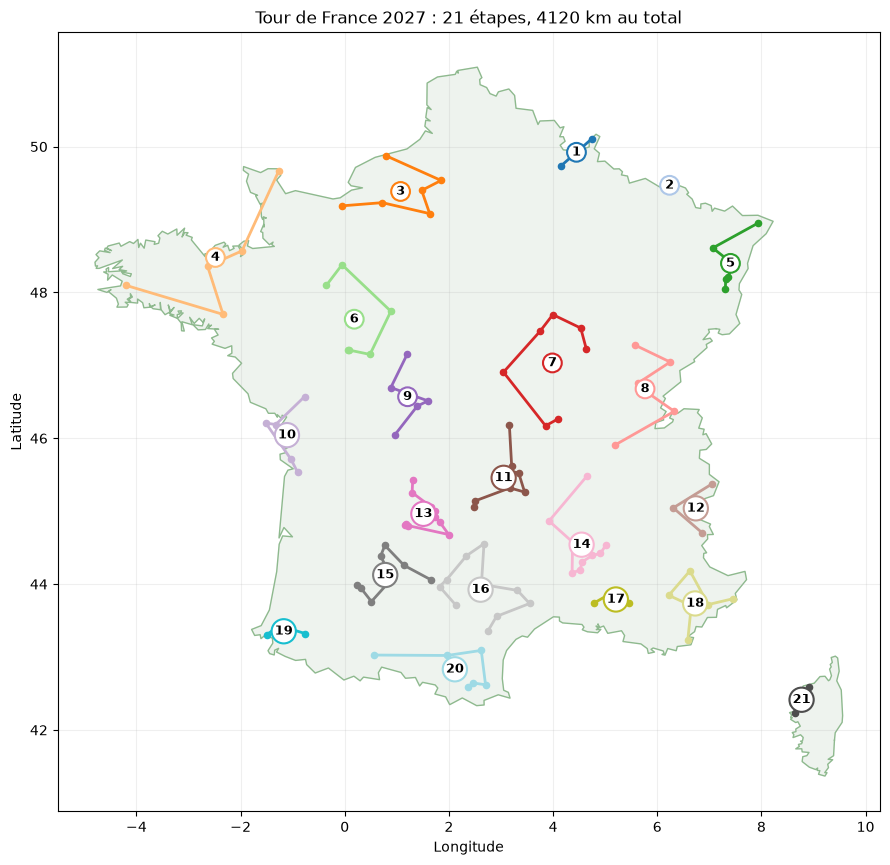

In [36]:
print_roadbook(villages, stage_paths, stage_distances)
plot_final_tour(villages, stage_paths, stage_distances)

## Analyser les distances des étapes

Cette cellule identifie l'étape la plus longue et la plus courte, puis compare visuellement les distances des 21 étapes dans un graphique.

Étape reine : l'étape 4, 410 km
La plus courte : l'étape 2, 0 km (presque un contre-la-montre !)


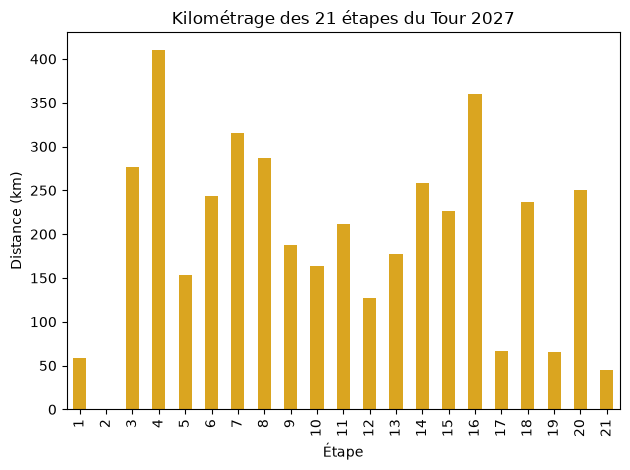

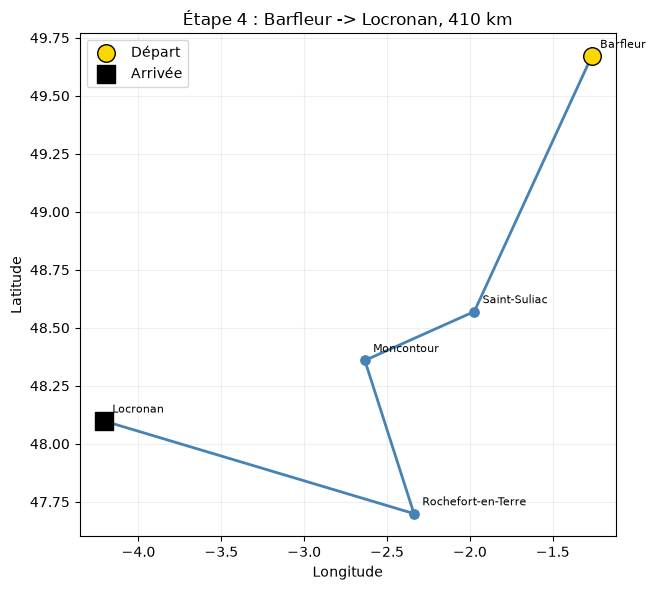

In [37]:
queen_stage = max(stage_distances, key=stage_distances.get)
sprint_stage = min(stage_distances, key=stage_distances.get)
print(f"Étape reine : l'étape {queen_stage}, {stage_distances[queen_stage]:.0f} km")
print(f"La plus courte : l'étape {sprint_stage}, {stage_distances[sprint_stage]:.0f} km (presque un contre-la-montre !)")

pd.Series(stage_distances).plot(kind="bar", color="goldenrod")
plt.title("Kilométrage des 21 étapes du Tour 2027")
plt.xlabel("Étape")
plt.ylabel("Distance (km)")
plt.tight_layout()
plt.show()

plot_stage_zoom(villages, stage_paths[queen_stage], queen_stage, stage_distances[queen_stage])

## Compétences mobilisées et acquis

Ce projet mobilise la manipulation de données géographiques, la visualisation cartographique, le clustering avec K-Means et la classification ascendante hiérarchique (CAH), ainsi que l'évaluation par score de silhouette. Il permet aussi d'apprendre à calculer des distances GPS avec la formule de Haversine et à optimiser des parcours grâce aux heuristiques du plus proche voisin et 2-opt.